In [3]:
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path
import datetime
import pandas as pd

In [2]:
def extract_and_plot_catchment(shape_path, gauge_id, gauge_id_col='gauge_id'):
    """
    Extract and plot the catchment shape for a given gauge_id from a shapefile.

    Parameters
    ----------
    shape_path : str
        Path to the CAMELS shapefile.
    gauge_id : int or str
        The gauge ID to extract.
    gauge_id_col : str
        The column name for gauge IDs in the shapefile (default: 'gauge_id').
    """
    # Load shapefile
    extent = gpd.read_file(shape_path)
    # Extract catchment
    extent_catchment = extent.loc[extent[gauge_id_col] == gauge_id]
    if len(extent_catchment) == 0:
        print(f"No catchment found with gauge ID {gauge_id}")
        return None
    # Plot
    ax = extent_catchment.plot(figsize=(8, 8), edgecolor='k', color='lightgrey')
    plt.title(f"Catchment for gauge ID {gauge_id}")
    plt.show()
    return extent_catchment

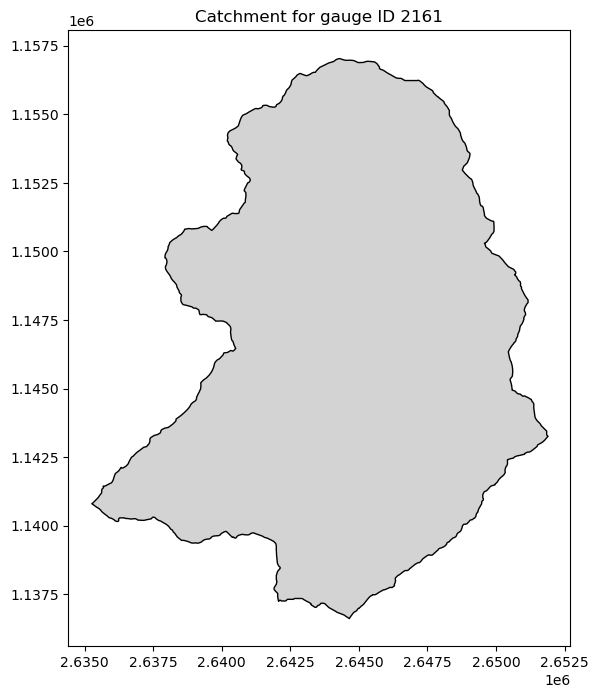

In [3]:
# Example usage:
shape_path = '/home/jberg/OneDrive/Raven_Switzerland/01_data/topo/CAMELS_CH_sub_catchments.shp'
catchment = extract_and_plot_catchment(shape_path, 2161)

In [4]:
def extract_and_plot_catchment_with_glaciers(shape_path, glacier_path, gauge_id, gauge_id_col='gauge_id'):
    # Load catchment shapefile
    catchments = gpd.read_file(shape_path)
    catchment = catchments.loc[catchments[gauge_id_col] == gauge_id]
    if len(catchment) == 0:
        print(f"No catchment found with gauge ID {gauge_id}")
        return None

    # Load glacier outlines
    glaciers = gpd.read_file(glacier_path)
    # Reproject glaciers to match catchment CRS
    glaciers = glaciers.to_crs(catchment.crs)
    # Clip glaciers to catchment
    glaciers_clipped = gpd.clip(glaciers, catchment)

    # Plot both
    ax = catchment.plot(figsize=(10, 10), edgecolor='k', color='lightgrey', label='Catchment')
    glaciers_clipped.plot(ax=ax, color='lightblue', edgecolor='blue', linewidth=1, label='Glaciers')
    plt.title(f"Catchment {gauge_id} with Glacier Outlines")
    plt.legend(['Catchment', 'Glaciers'])
    plt.show()
    return catchment, glaciers_clipped


/tmp/ipykernel_880388/3855936089.py:20: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend(['Catchment', 'Glaciers'])


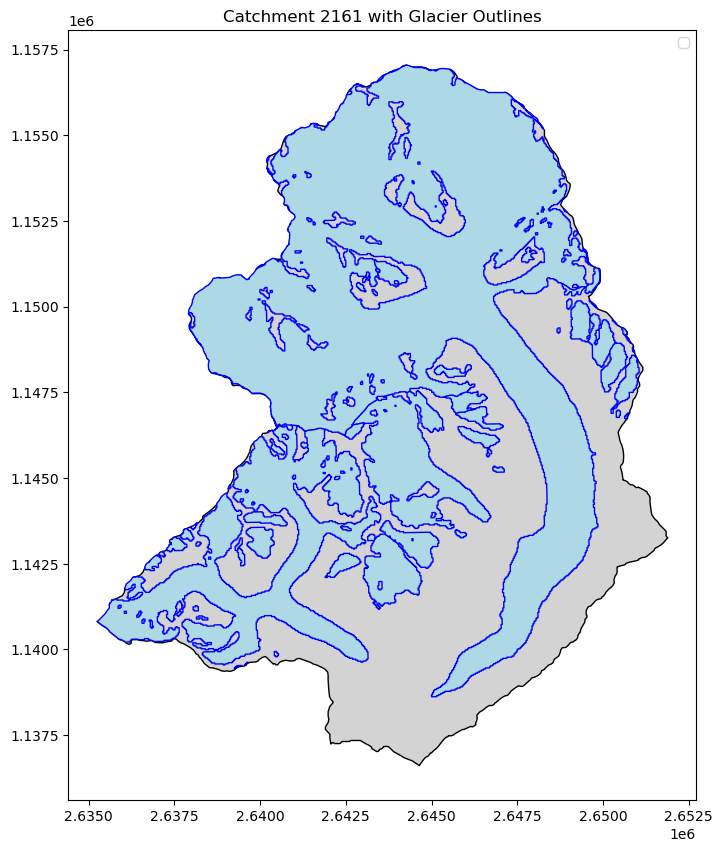

In [5]:
# Paths from your namelist.yaml
shape_path = '/home/jberg/OneDrive/Raven_Switzerland/01_data/topo/CAMELS_CH_sub_catchments.shp'
glacier_path = '/home/jberg/OneDrive/Raven_Switzerland/01_data/topo/11_rgi60_CentralEurope.shp'

# Example usage for gauge 2607
catchment, glaciers_clipped = extract_and_plot_catchment_with_glaciers(shape_path, glacier_path, 2161)

In [37]:
def process_glogem_data(gauge_id, base_dir, start_date, end_date, unit='mm', plot=True):
    from pathlib import Path
    import pandas as pd
    import geopandas as gpd
    import matplotlib.pyplot as plt
    import os
    from datetime import datetime, timedelta
    import matplotlib.dates as mdates
    from matplotlib.lines import Line2D

    # Base directory path
    glogem_dir = Path(r"/home/jberg/OneDrive/Raven_Switzerland/01_data/GloGEM")
    topo_dir = Path(base_dir)/ "02_model_setups_coupled" / f"catchment_{gauge_id}" / "topo_files"
    parsed_file = topo_dir / f"GloGEM_parsed_{gauge_id}.csv"

    # If cached file exists, load it
    if parsed_file.exists():
        print(f"Loading cached GloGEM data from {parsed_file}")
        scaled_df = pd.read_csv(parsed_file, parse_dates=['date'])
    else:
        # File paths using the provided catchment_id
        file_paths = {
            'icemelt': glogem_dir / f"GloGEM_icemelt_{gauge_id}.dat",
            'snowmelt': glogem_dir / f"GloGEM_snowmelt_{gauge_id}.dat",
            'output': glogem_dir / f"GloGEM_output_{gauge_id}.dat",
            'rain': glogem_dir / f"GloGEM_rain_{gauge_id}.dat"
        }
        catchment_shape_file = topo_dir / "HRU.shp"

        # Check if files exist
        for file_type, file_path in file_paths.items():
            if not file_path.exists():
                raise FileNotFoundError(f"File not found: {file_path}")

        # Parse start and end dates
        start = datetime.strptime(start_date, '%Y-%m-%d')
        end = datetime.strptime(end_date, '%Y-%m-%d')

        # Function to parse a GloGEM data file
        def parse_glogem_file(file_path):
            data = []
            areas = {}
            with open(file_path, 'r') as f:
                lines = f.readlines()
                for i, line in enumerate(lines):
                    if line.startswith("ID") or line.startswith("//"):
                        continue
                    parts = line.strip().split()
                    if len(parts) < 5:
                        continue
                    glacier_id = parts[0]
                    year = int(parts[1])
                    area = float(parts[2])
                    areas[glacier_id] = area
                    daily_values = [float(val) if val != '*' else 0.0 for val in parts[3:]]
                    start_date_g = datetime(year-1, 10, 1)
                    for day, value in enumerate(daily_values):
                        date = start_date_g + timedelta(days=day)
                        data.append({
                            'glacier_id': glacier_id,
                            'date': date,
                            'area': area,
                            'value': value
                        })
            return pd.DataFrame(data), areas

        print(f"Parsing GloGEM data files...")
        icemelt_df, icemelt_areas = parse_glogem_file(file_paths['icemelt'])
        snowmelt_df, snowmelt_areas = parse_glogem_file(file_paths['snowmelt'])
        rain_df, rain_areas = parse_glogem_file(file_paths['rain'])
        output_df, output_areas = parse_glogem_file(file_paths['output'])

        # Filter for the date range
        icemelt_df = icemelt_df[(icemelt_df['date'] >= start) & (icemelt_df['date'] <= end)]
        snowmelt_df = snowmelt_df[(snowmelt_df['date'] >= start) & (snowmelt_df['date'] <= end)]
        rain_df = rain_df[(rain_df['date'] >= start) & (rain_df['date'] <= end)]
        output_df = output_df[(output_df['date'] >= start) & (output_df['date'] <= end)]

        # read in HRU shapfile
        catchment = gpd.read_file(catchment_shape_file)

        # Create a dataframe with area per Glacier_Cl
        glacier_areas = catchment.groupby('Glacier_Cl').agg({'Area_km2': 'sum'}).reset_index()

        # Calculate total area
        glacier_area = glacier_areas['Area_km2'].sum()
        print(glacier_area)
        total_area = catchment['Area_km2'].sum()
        print(total_area)

        # Add percentage column
        percentage = (glacier_area / total_area) * 100
        print(percentage)

        # Create a dictionary mapping from glacier_id to area
        area_dict = {}
        for _, row in glacier_areas.iterrows():
            glacier_id = row['Glacier_Cl'][-5:]
            area_dict[glacier_id] = row['Area_km2']
        print(f"Glacier areas: {area_dict}")

        # Update the area in all relevant DataFrames
        for df in [icemelt_df, snowmelt_df, rain_df, output_df]:
            for glacier_id, new_area in area_dict.items():
                mask = df['glacier_id'] == glacier_id
                if mask.any():
                    old_areas = df.loc[mask, 'area'].unique()
                    df.loc[mask, 'area'] = new_area
                    print(f"Glacier ID {glacier_id}: switched area(s) {old_areas} -> {new_area} for {mask.sum()} rows in {df}")

        # Calculate catchment average runoff (weighted by glacier area)
        def calculate_catchment_average(df, areas):
            catchment_area = sum(areas.values())
            print(f"Total glacier area used for averaging: {catchment_area:.6f} km²")
            print("Glacier IDs and areas used in averaging:")
            print(df.groupby('glacier_id')['area'].unique())
            df['weighted_value'] = df['value'] * df['area']
            daily_sum = df.groupby('date')['weighted_value'].sum().reset_index()
            daily_sum['catchment_avg'] = daily_sum['weighted_value'] / catchment_area
            print("Sample daily weighted melt sums and catchment averages:")
            print(daily_sum.head())
            return daily_sum[['date', 'catchment_avg']]

        print(f"Calculating catchment average runoff...")
        icemelt_avg = calculate_catchment_average(icemelt_df, area_dict)
        snowmelt_avg = calculate_catchment_average(snowmelt_df, area_dict)
        rain_avg = calculate_catchment_average(rain_df, area_dict)
        output_avg = calculate_catchment_average(output_df, area_dict)

        # Combine all dataframes
        result_df = pd.merge(icemelt_avg, snowmelt_avg, on='date', suffixes=('_icemelt', '_snowmelt'))
        result_df = pd.merge(result_df, rain_avg, on='date')
        result_df = pd.merge(result_df, output_avg, on='date')
        result_df.columns = ['date', 'glacier_melt', 'snowmelt', 'rainfall', 'total_output']

        # Convert units if necessary
        if unit == 'm3':
            catchment_area = sum(icemelt_areas.values()) * 1000000  # Convert km² to m²
            result_df['glacier_melt'] = result_df['glacier_melt'] * catchment_area / 1000  # mm to m³
            result_df['snowmelt'] = result_df['snowmelt'] * catchment_area / 1000
            result_df['rainfall'] = result_df['rainfall'] * catchment_area / 1000
            result_df['total_output'] = result_df['total_output'] * catchment_area / 1000

        # Create a copy to avoid modifying the original
        scaled_df = result_df.copy()

        # scaling factor is the percentage of glaciated area
        scaling_factor = percentage / 100

        scaled_df['glacier_melt'] = scaled_df['glacier_melt'] * scaling_factor
        scaled_df['snowmelt'] = scaled_df['snowmelt'] * scaling_factor
        scaled_df['total_output'] = scaled_df['total_output'] * scaling_factor
        scaled_df['rainfall'] = scaled_df['rainfall'] * scaling_factor

        # After creating scaled_df, save to CSV
        os.makedirs(topo_dir, exist_ok=True)
        scaled_df.to_csv(parsed_file, index=False)
        print(f"Saved parsed GloGEM data to {parsed_file}")

    # Now, always make the plots if requested
    if plot:
        # Monthly regime plot
        scaled_df['year'] = scaled_df['date'].dt.year
        scaled_df['month'] = scaled_df['date'].dt.month
        monthly_regime = scaled_df.groupby('month').agg({
            'glacier_melt': 'mean',
            'snowmelt': 'mean',
            'total_output': 'mean',
            'rainfall': 'mean'
        }).reset_index()
        print(f"Creating regime plot...")
        plt.figure(figsize=(12, 6))
        plt.plot(monthly_regime['month'], monthly_regime['glacier_melt'], 'b-', label='Glacier Melt')
        plt.plot(monthly_regime['month'], monthly_regime['snowmelt'], 'c-', label='Snowmelt')
        plt.plot(monthly_regime['month'], monthly_regime['total_output'], 'k-', label='Total Output')
        plt.plot(monthly_regime['month'], monthly_regime['rainfall'], 'g-', label='Rainfall')
        plt.xlabel('Month')
        unit_label = 'mm' if unit == 'mm' else 'm³'
        plt.ylabel(f'Average Runoff ({unit_label})')
        plt.title(f'Monthly Regime for Catchment {gauge_id} ({start_date} to {end_date})')
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
        plt.legend()
        plt.tight_layout()
        plt.show()

         # Daily regime plot
        scaled_df['day_of_year'] = scaled_df['date'].dt.dayofyear
        daily_avg = scaled_df.groupby('day_of_year').agg({
            'glacier_melt': 'mean',
            'snowmelt': 'mean',
            'total_output': 'mean',
            'rainfall': 'mean'
        }).reset_index()
        daily_avg['date'] = pd.to_datetime('2001-01-01') + pd.to_timedelta(daily_avg['day_of_year'] - 1, unit='days')
        fig, ax = plt.subplots(figsize=(10, 6))
        l1, = ax.plot(daily_avg['date'], daily_avg['total_output'], 'k-', label='Total Output', linewidth=2.5)
        l2, = ax.plot(daily_avg['date'], daily_avg['snowmelt'], 'c-', label='Snowmelt', linewidth=2.2)
        l3, = ax.plot(daily_avg['date'], daily_avg['glacier_melt'], 'b-', label='Glacier Melt', linewidth=2.2)
        l4, = ax.plot(daily_avg['date'], daily_avg['rainfall'], 'g-', label='Rainfall', linewidth=2.2)
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
        ax.set_xlabel('Date', fontsize=20, fontweight='bold')
        ax.set_ylabel('Runoff [mm/day]', fontsize=20, fontweight='bold')
        ax.grid(False)
        ax.tick_params(axis='both', which='major', labelsize=0, length=0)
        ax.tick_params(axis='x', which='major', labelsize=0, length=0)
        ax.tick_params(axis='y', which='major', labelsize=0, length=0)

        # Custom legend with thick lines
        legend_handles = [
            Line2D([0], [0], color='k', lw=5, label='Total Output'),
            Line2D([0], [0], color='c', lw=5, label='Snowmelt'),
            Line2D([0], [0], color='b', lw=5, label='Glacier Melt'),
            Line2D([0], [0], color='g', lw=5, label='Rainfall')
        ]
        ax.legend(handles=legend_handles, fontsize=18, loc="upper left")
        plt.tight_layout()

        # Save daily regime figure
        save_dir = '/home/jberg/OneDrive/Paper_writing/Paper_1/Figures/methodology'
        os.makedirs(save_dir, exist_ok=True)
        plt.savefig(f'{save_dir}/glogem_daily_regime_catchment_{gauge_id}.png',
                    bbox_inches='tight', transparent=True, dpi=300)


        plt.show()

    return scaled_df

Loading cached GloGEM data from /home/jberg/OneDrive/Raven_Switzerland/04_runs_final_paperdraft/02_model_setups_coupled/catchment_2161/topo_files/GloGEM_parsed_2161.csv
Creating regime plot...


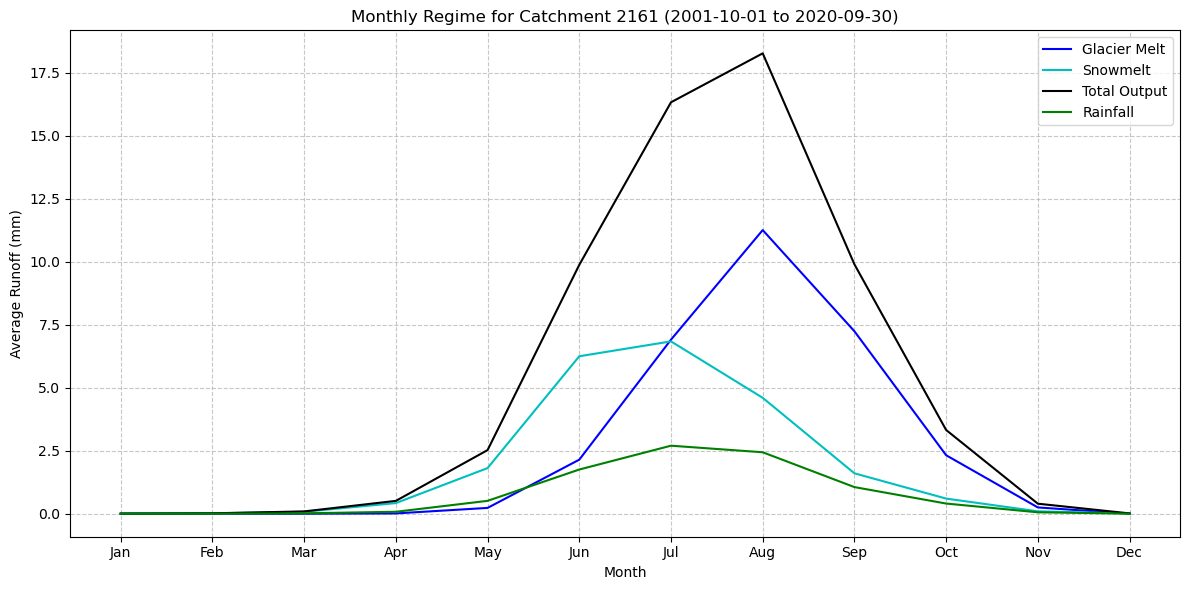

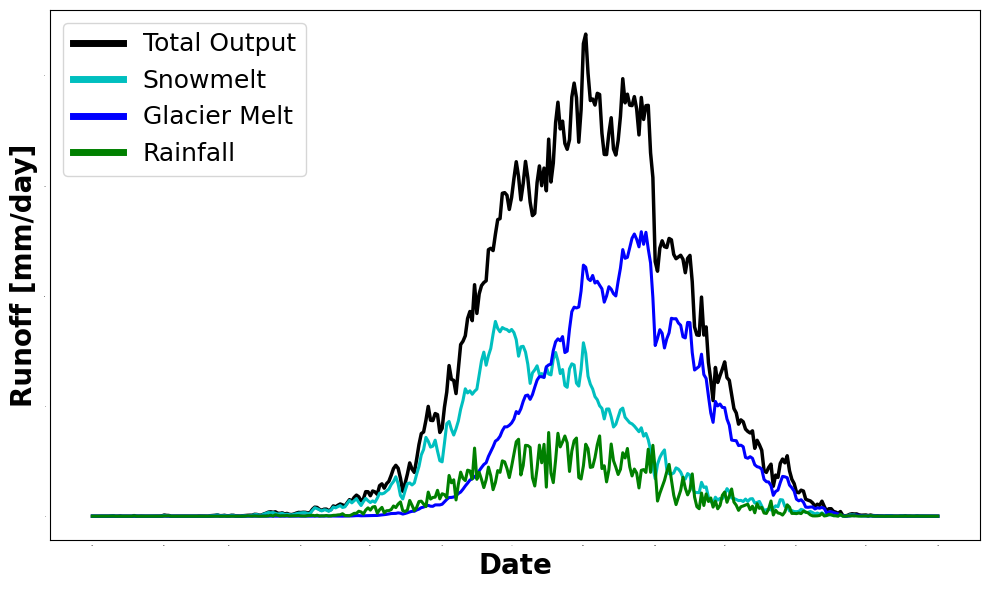

,date,glacier_melt,snowmelt,rainfall,total_output,year,month,day_of_year
0,2000-01-01,0.0,0.000000e+00,0.0,0.000000e+00,2000,1,1
1,2000-01-02,0.0,9.863506e-07,0.0,9.863506e-07,2000,1,2
2,2000-01-03,0.0,6.904455e-06,0.0,6.904455e-06,2000,1,3
3,2000-01-04,0.0,3.945403e-06,0.0,3.945403e-06,2000,1,4
4,2000-01-05,0.0,0.000000e+00,0.0,9.863506e-07,2000,1,5
...,...,...,...,...,...,...,...,...
7660,2020-12-27,0.0,0.000000e+00,0.0,0.000000e+00,2020,12,362
7661,2020-12-28,0.0,0.000000e+00,0.0,0.000000e+00,2020,12,363
7662,2020-12-29,0.0,0.000000e+00,0.0,0.000000e+00,2020,12,364
7663,2020-12-30,0.0,0.000000e+00,0.0,0.000000e+00,2020,12,365


In [38]:
base_dir = r"/home/jberg/OneDrive/Raven_Switzerland/04_runs_final_paperdraft"
gauge_id = 2161
start_date = '2001-10-01'
end_date = '2020-09-30'

process_glogem_data(gauge_id, base_dir, start_date, end_date, unit='mm', plot=True)

In [38]:
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

def plot_catchment_dem(shape_path, dem_path, gauge_id, gauge_id_col='gauge_id', save_figs=True):
    import os
    import matplotlib.pyplot as plt
    
    # Clear any existing figures
    plt.close('all')
    
    catchments = gpd.read_file(shape_path)
    catchment = catchments.loc[catchments[gauge_id_col] == gauge_id]
    if len(catchment) == 0:
        print(f"No catchment found with gauge ID {gauge_id}")
        return None

    with rasterio.open(dem_path) as src:
        catchment = catchment.to_crs(src.crs)
        out_image, out_transform = mask(src, catchment.geometry, crop=True)
        out_image = out_image[0]  # First band

        # Mask no-data values
        nodata = src.nodata
        if nodata is not None:
            out_image = np.where(out_image == nodata, np.nan, out_image)

    # Set colormap
    try:
        import cmcrameri.cm as cmc
        original_cmap = cmc.fes
        colors = original_cmap(np.linspace(0.5, 1, 256))
        cmap = mcolors.ListedColormap(colors)
    except ImportError:
        cmap = 'terrain'  # fallback

    # Create save directory if it doesn't exist
    save_dir = '/home/jberg/OneDrive/Paper_writing/Paper_1/Figures/methodology'
    os.makedirs(save_dir, exist_ok=True)

    # Create figure with desired size
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Force the axis to fill the entire figure
    ax.set_position([0, 0, 1, 1])  # [left, bottom, width, height] in figure coordinates
    
    im = ax.imshow(out_image, cmap=cmap, extent=[
        out_transform[2],
        out_transform[2] + out_transform[0] * out_image.shape[1],
        out_transform[5] + out_transform[4] * out_image.shape[0],
        out_transform[5]
    ], aspect='auto')  # aspect='auto' allows stretching to fill the axes
    
    # Add colorbar - position it manually to account for full axes
    cbar = plt.colorbar(im, ax=ax, shrink=0.7, pad=0.02)
    cbar.set_label('Elevation [m]', fontsize=34, fontweight='bold')
    cbar.set_ticks([])  # Remove all ticks
    cbar.ax.tick_params(labelsize=0, length=0)  # Remove tick labels and ticks
    ax.axis('off')
    
    # Save figure if requested
    if save_figs:
        plt.savefig(f'{save_dir}/dem_catchment_{gauge_id}.png', 
                   bbox_inches='tight', transparent=True, dpi=300)
    
    plt.show()
# ...existing code...
    # Reset matplotlib params
    plt.rcdefaults()

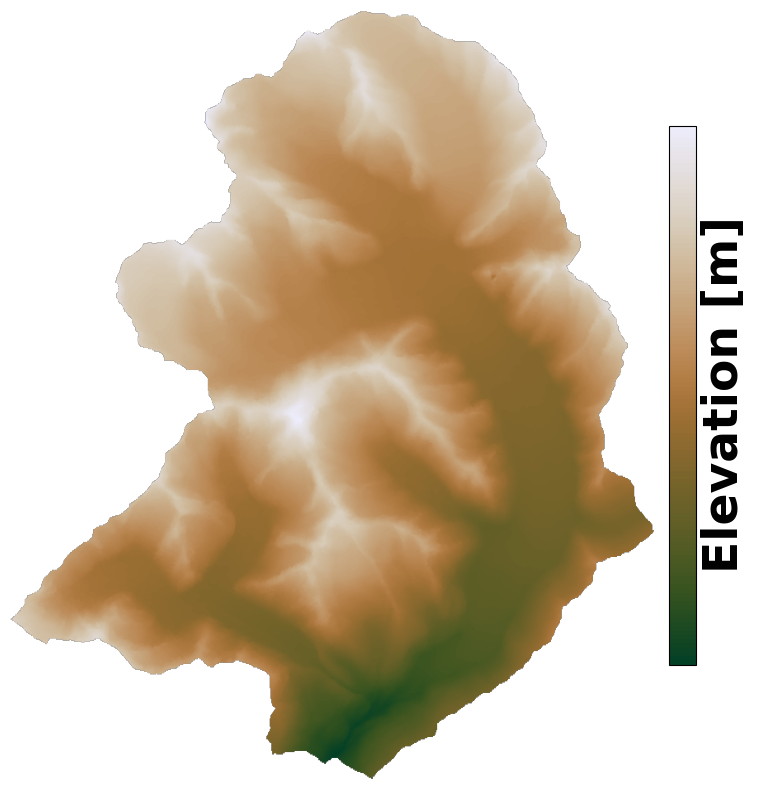

In [39]:
# Example usage:
shape_path = '/home/jberg/OneDrive/Raven_Switzerland/01_data/topo/CAMELS_CH_sub_catchments.shp'
dem_path = '/home/jberg/OneDrive/Raven_Switzerland/01_data/topo/SRTM_dem.tif'
plot_catchment_dem(shape_path, dem_path, 2161)

In [34]:
def plot_first_timestep_nc(shape_path, base_dir, gauge_id, precip_file='prec_Meteoswiss.nc', temp_file='temp_Meteoswiss.nc', gauge_id_col='gauge_id', save_figs=True):
    import geopandas as gpd
    import matplotlib.pyplot as plt
    import xarray as xr
    import os

    # Build file paths
    data_dir = f"{base_dir}/catchment_{gauge_id}/HBV/data_obs"
    precip_path = f"{data_dir}/{precip_file}"
    temp_path = f"{data_dir}/{temp_file}"

    # Load catchment shapefile
    catchments = gpd.read_file(shape_path)
    catchment = catchments.loc[catchments[gauge_id_col] == gauge_id]
    if len(catchment) == 0:
        print(f"No catchment found with gauge ID {gauge_id}")
        return None

    # Load NetCDF files
    precip_ds = xr.open_dataset(precip_path)
    temp_ds = xr.open_dataset(temp_path)

    # Use the correct variable names - RhiresD for precipitation
    precip_data = precip_ds['RhiresD'].isel(time=29)
    
    # For temperature, find the variable with time dimension
    temp_var = None
    for var in temp_ds.data_vars:
        if 'time' in temp_ds[var].dims:
            temp_var = var
            break
    
    if temp_var is None:
        print("No temperature variable with time dimension found!")
        return
    
    temp_data = temp_ds[temp_var].isel(time=29)

    # Get E/N coordinates
    x = precip_ds['E'].values
    y = precip_ds['N'].values

    # Create save directory if it doesn't exist
    save_dir = '/home/jberg/OneDrive/Paper_writing/Paper_1/Figures/methodology'
    os.makedirs(save_dir, exist_ok=True)

    # Plot temperature
    # Plot temperature
    plt.figure(figsize=(10, 8))
    temp_plot = plt.pcolormesh(x, y, temp_data.values, cmap='RdBu_r', shading='auto')
    catchment.boundary.plot(ax=plt.gca(), edgecolor='black', linewidth=2)
    #plt.title('Temperature [°C]', fontsize=28, fontweight='bold')  # <-- Added title
    cbar_temp = plt.colorbar(temp_plot, shrink=0.7)
    cbar_temp.set_label('Temperature [°C]', fontsize=34, fontweight='bold')
    cbar_temp.set_ticks([])  # Remove all ticks
    cbar_temp.ax.tick_params(labelsize=0, length=0)  # Remove tick labels and ticks
    plt.axis('off')
    plt.tight_layout()
    
    if save_figs:
        plt.savefig(f'{save_dir}/temperature_catchment_{gauge_id}.png', 
                   bbox_inches='tight', transparent=True, dpi=300)
    plt.show()

    # Plot precipitation
    plt.figure(figsize=(10, 8))
    precip_plot = plt.pcolormesh(x, y, precip_data.values, cmap='Blues', shading='auto')
    catchment.boundary.plot(ax=plt.gca(), edgecolor='black', linewidth=2)
    #plt.title('Precipitation [mm]', fontsize=28, fontweight='bold')  # <-- Added title
    cbar_precip = plt.colorbar(precip_plot, shrink=0.7)
    cbar_precip.set_label('Precipitation [mm]', fontsize=34, fontweight='bold')
    cbar_precip.set_ticks([])  # Remove all ticks
    cbar_precip.ax.tick_params(labelsize=0, length=0)  # Remove tick labels and ticks
    plt.axis('off')
    plt.tight_layout()
    
    if save_figs:
        plt.savefig(f'{save_dir}/precipitation_catchment_{gauge_id}.png', 
                   bbox_inches='tight', transparent=True, dpi=300)
    plt.show()

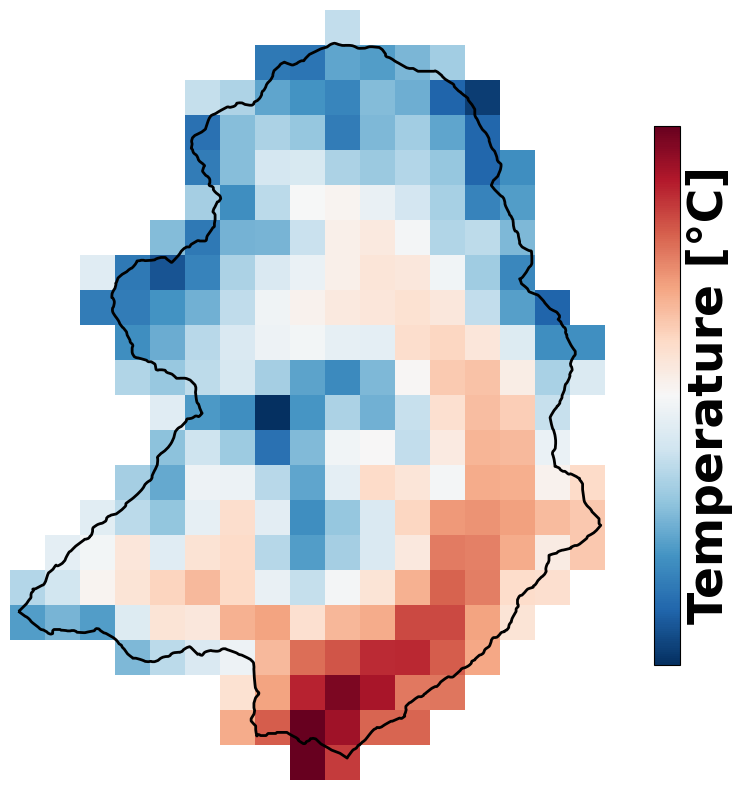

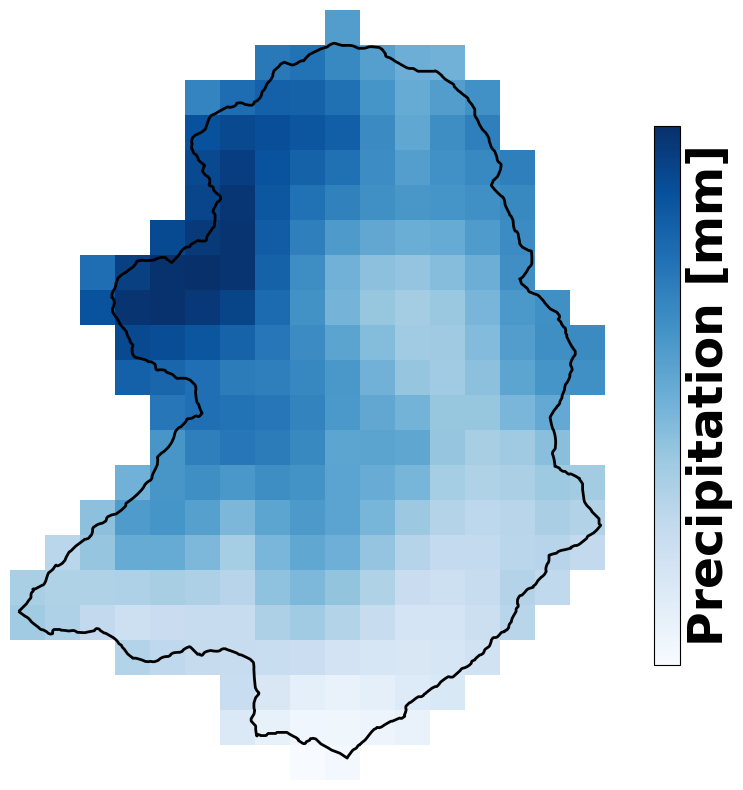

In [35]:
# Example usage:
shape_path = '/home/jberg/OneDrive/Raven_Switzerland/01_data/topo/CAMELS_CH_sub_catchments.shp'
base_dir = '/home/jberg/OneDrive/Raven_Switzerland/02_model_setups'
gauge_id = 2161
plot_first_timestep_nc(shape_path, base_dir, gauge_id)

In [36]:
def plot_catchment_hru_landuse(base_dir, gauge_id, save_figs=True):
    import geopandas as gpd
    import matplotlib.pyplot as plt
    import pandas as pd
    import os
    from matplotlib.patches import Rectangle

    # Build file path to HRU shapefile
    hru_path = f"{base_dir}/catchment_{gauge_id}/topo_files/HRU.shp"

    # Check if file exists
    if not os.path.exists(hru_path):
        print(f"HRU shapefile not found at {hru_path}")
        return None

    # Load HRU shapefile
    hru_gdf = gpd.read_file(hru_path)

    # Check if Landuse_Cl column exists
    if 'Landuse_Cl' not in hru_gdf.columns:
        print("Landuse_Cl column not found in HRU shapefile")
        print("Available columns:", hru_gdf.columns.tolist())
        return None

    # Print unique values for debugging
    print("Unique landuse values:", sorted(hru_gdf['Landuse_Cl'].dropna().unique()))

    # Define landuse labels and colors
    landuse_labels = {
        1: 'Forest',
        2: 'Open',
        3: 'Crop',
        4: 'Built',
        5: 'Rock',
        6: 'Lake',
        7: 'Glacier',
        8: 'Masked Glacier'
    }

    # Define colors for each landuse type
    landuse_colors = {
        1: 'darkgreen',    # Forest - dark green
        2: 'lightgreen',   # Open - light green  
        3: 'yellow',       # Crop - yellow
        4: 'red',          # Built - red
        5: '#D2B48C',      # Rock - tan
        6: 'blue',         # Lake - blue
        7: 'lightblue',    # Glacier - light blue
        8: 'lightgrey'     # Masked Glacier - light grey
    }

    # Convert to integer and get unique classes
    hru_gdf['Landuse_Cl_int'] = hru_gdf['Landuse_Cl'].astype(int)
    unique_classes = sorted(hru_gdf['Landuse_Cl_int'].unique())

    # Create save directory if it doesn't exist
    save_dir = '/home/jberg/OneDrive/Paper_writing/Paper_1/Figures/methodology'
    os.makedirs(save_dir, exist_ok=True)

    # Create the plot
    fig, ax = plt.subplots(figsize=(10, 8))

    # Plot each landuse class with its specific color
    for landuse_class in unique_classes:
        subset = hru_gdf[hru_gdf['Landuse_Cl_int'] == landuse_class]
        color = landuse_colors.get(landuse_class, 'black')
        subset.plot(ax=ax, color=color, edgecolor='black', linewidth=0.5)

    # Customize plot
    ax.set_aspect('equal')
    ax.axis('off')
    plt.tight_layout()

    # Add conceptual color boxes and vertical "Landuse" label on the right side
    box_size = 0.05
    spacing = 0.01
    x_right = 0.8  # Right side of figure (0.0 left, 1.0 right)
    total_height = len(unique_classes) * box_size + (len(unique_classes) - 1) * spacing
    y0 = 0.5 - total_height / 2

    for i, landuse_class in enumerate(unique_classes):
        color = landuse_colors.get(landuse_class, 'black')
        fig.add_artist(
            Rectangle(
                (x_right, y0 + i * (box_size + spacing)),
                box_size,
                box_size,
                facecolor=color,
                edgecolor='black',
                transform=fig.transFigure,
                zorder=10
            )
        )
    # Add vertical label, rotated 90°, centered with the boxes
    fig.text(
        x_right + box_size + 0.02,
        0.5,
        "Landuse",
        fontsize=34,
        fontweight='bold',
        va='center',
        ha='left',
        rotation=90,
        transform=fig.transFigure
    )

    # Save figure if requested
    if save_figs:
        plt.savefig(f'{save_dir}/landuse_hru_catchment_{gauge_id}.png',
                    bbox_inches='tight', transparent=True, dpi=300)

    plt.show()

    # Print summary
    print(f"Landuse distribution for catchment {gauge_id}:")
    landuse_summary = hru_gdf['Landuse_Cl_int'].value_counts().sort_index()
    for landuse_class, count in landuse_summary.items():
        label = landuse_labels.get(landuse_class, "Unknown")
        print(f"  Class {landuse_class} ({label}): {count} HRUs")

    return hru_gdf

Unique landuse values: [np.int64(1), np.int64(2), np.int64(5), np.int64(6), np.int64(7)]


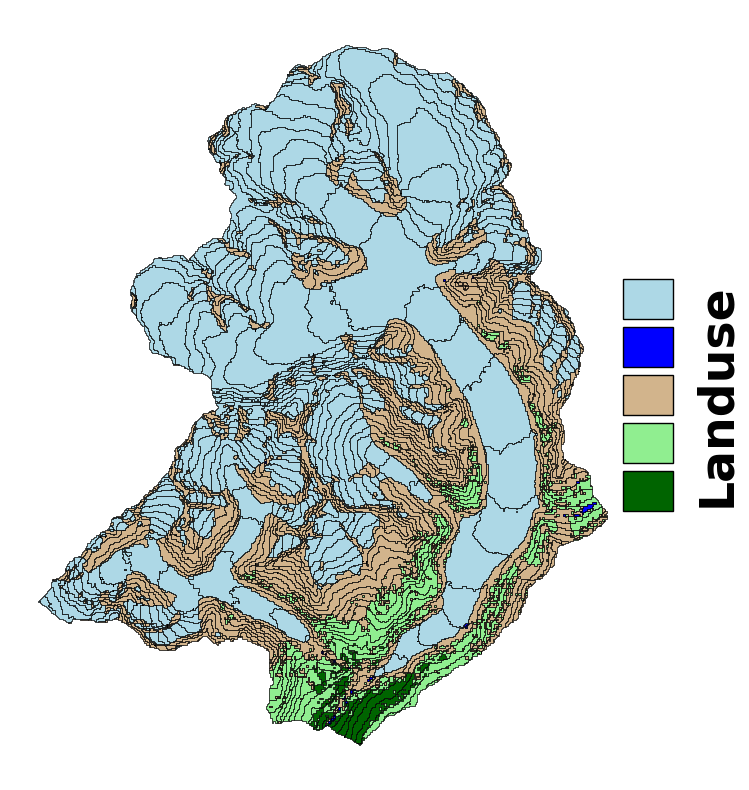

Landuse distribution for catchment 2161:
  Class 1 (Forest): 9 HRUs
  Class 2 (Open): 19 HRUs
  Class 5 (Rock): 28 HRUs
  Class 6 (Lake): 14 HRUs
  Class 7 (Glacier): 27 HRUs


In [37]:
# Example usage:
base_dir = '/home/jberg/OneDrive/Raven_Switzerland/02_model_setups'
gauge_id = 2161
hru_data = plot_catchment_hru_landuse(base_dir, gauge_id)

In [4]:
def load_hydrograph_data(gauge_id, config_folder, base_dir):
    """
    Load hydrograph data from a specific configuration folder.

    Parameters
    ----------
    gauge_id : int or str
        The gauge ID to extract.
    config_folder : str
        The configuration folder name (e.g., '02_model_setups', '02_model_setups_coupled').
    base_dir : str
        The base directory (e.g., '/home/jberg/OneDrive/Raven_Switzerland/04_runs_final_paperdraft').
    """
    from pathlib import Path
    import pandas as pd

    # Path for hydrograph file
    model_dir = Path(base_dir) / config_folder / f"catchment_{gauge_id}" / "HBV"
    hydro_file = model_dir / "output" / f"{gauge_id}_HBV_Hydrographs.csv"

    print(f"Loading hydrograph data from config folder '{config_folder}':")
    print(f"  - File: {hydro_file}")

    try:
        # Read the CSV file
        df = pd.read_csv(hydro_file)

        # Convert date column to datetime
        if 'date' in df.columns:
            df['date'] = pd.to_datetime(df['date'])

        # Identify the simulated and observed columns
        sim_col = None
        obs_col = None

        # Look for columns matching the pattern for simulated and observed flow
        for col in df.columns:
            if '[m3/s]' in col and 'observed' not in col.lower():
                sim_col = col
            elif '[m3/s]' in col and 'observed' in col.lower():
                obs_col = col

        if not sim_col:
            # Try alternative column naming patterns
            for col in df.columns:
                if col.endswith('[m3/s]') and not col.endswith('(observed) [m3/s]'):
                    sim_col = col
                elif col.endswith('(observed) [m3/s]'):
                    obs_col = col

        # Rename columns for consistency
        renamed_df = df.copy()
        if sim_col:
            renamed_df['sim_Q'] = df[sim_col]
        if obs_col:
            renamed_df['obs_Q'] = df[obs_col]

        print(f"  - Found columns: sim={sim_col}, obs={obs_col}")
        print(f"  - Data range: {renamed_df['date'].min()} to {renamed_df['date'].max()}")

        return renamed_df

    except Exception as e:
        print(f"  - Error loading data: {e}")
        return None

In [5]:
def plot_hydrograph_example_years(gauge_id, config_folder, base_dir, years=[2015, 2016], save_figs=True):
    """Plot hydrograph for specific example years with clean style"""
    import matplotlib.pyplot as plt
    import matplotlib.dates as mdates
    from matplotlib.lines import Line2D
    import os

    # Load hydrograph data
    df = load_hydrograph_data(gauge_id, config_folder, base_dir)

    if df is None:
        print("Failed to load hydrograph data")
        return None

    # Create save directory if it doesn't exist
    save_dir = '/home/jberg/OneDrive/Paper_writing/Paper_1/Figures/methodology'
    os.makedirs(save_dir, exist_ok=True)

    # Filter data for the specified years
    df['year'] = df['date'].dt.year
    df_filtered = df[df['year'].isin(years)]

    if len(df_filtered) == 0:
        print(f"No data found for years {years}")
        return None

    # Choose a visually distinct color for simulated streamflow
    sim_color = 'dodgerblue'

    # Create the plot
    fig, ax = plt.subplots(figsize=(12, 6))

    # Plot observed streamflow (black)
    if 'obs_Q' in df_filtered.columns:
        ax.plot(df_filtered['date'], df_filtered['obs_Q'],
                color='black', linewidth=2.5)

    # Plot simulated streamflow (distinct color)
    if 'sim_Q' in df_filtered.columns:
        ax.plot(df_filtered['date'], df_filtered['sim_Q'],
                color=sim_color, linewidth=2.5)

    # Customize the plot
    ax.set_ylabel('Streamflow [m³/s]', fontsize=28, fontweight='bold')
    ax.set_xlabel('Date', fontsize=28, fontweight='bold')
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=22)

    ax.tick_params(axis='both', which='both', labelsize=0, length=0)
    ax.grid(False)

    legend_handles = [
        Line2D([0], [0], color='black', lw=6, label='Observed'),
        Line2D([0], [0], color=sim_color, lw=6, label='Simulated')
    ]
    ax.legend(handles=legend_handles, fontsize=24, loc='upper right')

    plt.tight_layout()

    if save_figs:
        years_str = '_'.join(map(str, years))
        plt.savefig(f'{save_dir}/hydrograph_{config_folder}_catchment_{gauge_id}_{years_str}.png',
                    bbox_inches='tight', transparent=True, dpi=300)

    plt.show()

    return df_filtered

Loading hydrograph data from config folder '02_model_setups_coupled':
  - File: /home/jberg/OneDrive/Raven_Switzerland/04_runs_final_paperdraft/02_model_setups_coupled/catchment_2161/HBV/output/2161_HBV_Hydrographs.csv
  - Found columns: sim=2161 [m3/s], obs=2161 (observed) [m3/s]
  - Data range: 2000-01-01 00:00:00 to 2020-12-31 00:00:00


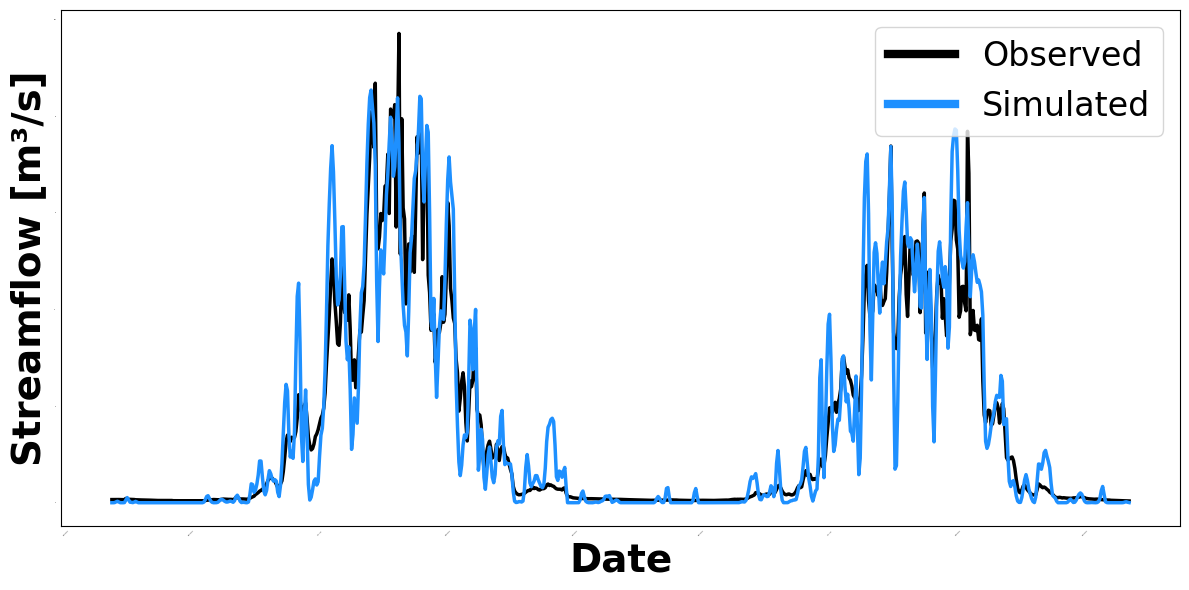

In [8]:
# Example usage:
base_dir = '/home/jberg/OneDrive/Raven_Switzerland/04_runs_final_paperdraft'
gauge_id = 2161
config = '02_model_setups_coupled'  # or whatever your config suffix is
hydrograph_data = plot_hydrograph_example_years(gauge_id, config, base_dir, years=[2015, 2016])

In [1]:
def plot_unit_hydrograph(save_figs=True):
    """Create a conceptual unit hydrograph for catchment hydrology"""
    import matplotlib.pyplot as plt
    import numpy as np
    import os
    import math

    save_dir = '/home/jberg/OneDrive/Paper_writing/Paper_1/Figures/methodology'
    os.makedirs(save_dir, exist_ok=True)

    time = np.linspace(0, 15, 150)
    shape = 2.5
    scale = 2.0
    unit_hydrograph = (time**(shape-1) * np.exp(-time/scale)) / (scale**shape * math.gamma(shape))
    unit_hydrograph = unit_hydrograph / np.trapz(unit_hydrograph, time)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.fill_between(time, unit_hydrograph, alpha=0.7, color='steelblue')
    ax.plot(time, unit_hydrograph, 'b-', linewidth=3)

    # Hide axis lines and ticks, but keep labels
    ax.set_xlabel('Time (hours)', fontsize=36, labelpad=20, fontweight='bold')
    ax.set_ylabel('Unit Response', fontsize=36, labelpad=20, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.tick_params(axis='both', which='both', labelsize=0, length=0)
    ax.set_xticks([])
    ax.set_yticks([])

    plt.tight_layout()
    if save_figs:
        plt.savefig(f'{save_dir}/unit_hydrograph_conceptual.png',
                    bbox_inches='tight', transparent=True, dpi=300)
    plt.show()
    return fig

/tmp/ipykernel_885980/1823275569.py:15: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  unit_hydrograph = unit_hydrograph / np.trapz(unit_hydrograph, time)


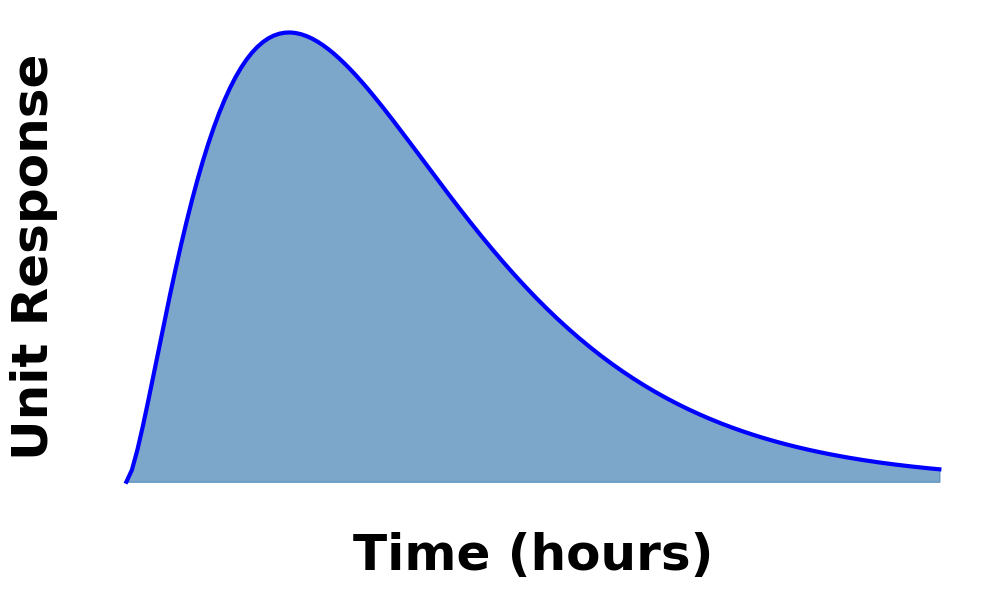

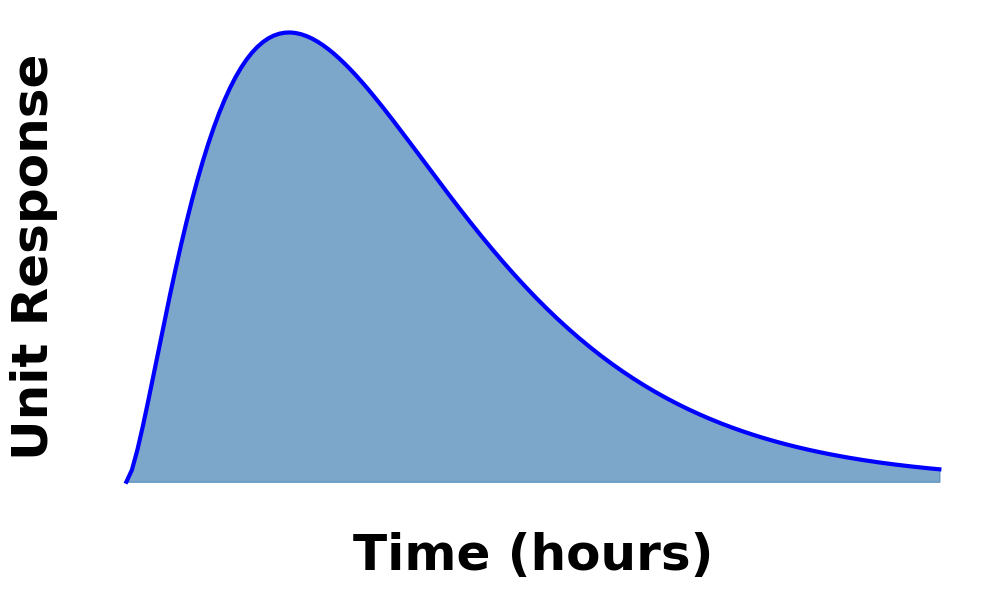

In [2]:
plot_unit_hydrograph()

In [33]:
def plot_hru_precipitation(base_dir, gauge_id, time_step=8, save_figs=True):
    """Plot precipitation values for each HRU from NetCDF data"""
    import geopandas as gpd
    import matplotlib.pyplot as plt
    import xarray as xr
    import numpy as np
    import os

    # Build file paths
    data_dir = f"{base_dir}/catchment_{gauge_id}/HBV/data_obs"
    precip_path = f"{data_dir}/prec_Meteoswiss_new.nc"
    hru_path = f"{base_dir}/catchment_{gauge_id}/topo_files/HRU.shp"

    # Check if files exist
    if not os.path.exists(precip_path):
        print(f"NetCDF file not found at {precip_path}")
        return None

    if not os.path.exists(hru_path):
        print(f"HRU shapefile not found at {hru_path}")
        return None

    # Load NetCDF precipitation data
    try:
        precip_ds = xr.open_dataset(precip_path)
        print(f"NetCDF variables: {list(precip_ds.data_vars.keys())}")
        print(f"NetCDF dimensions: {list(precip_ds.dims.keys())}")

        # Get precipitation data for specified time step
        precip_data = precip_ds['data'].isel(time=time_step)
        print(f"Precipitation data shape: {precip_data.shape}")
        print(f"Precipitation range: {precip_data.min().values:.2f} to {precip_data.max().values:.2f}")

        # Extract values and ensure they're 1D
        if len(precip_data.shape) == 2:
            precip_values = precip_data.values.flatten()
        else:
            precip_values = precip_data.values

    except Exception as e:
        print(f"Error loading NetCDF data: {e}")
        return None

    # Load HRU shapefile
    try:
        hru_gdf = gpd.read_file(hru_path)
        print(f"Number of HRUs: {len(hru_gdf)}")
        print(f"HRU columns: {hru_gdf.columns.tolist()}")

        # CRITICAL FIX: Sort HRUs the same way as in the preprocessing script
        hru_id_col = 'HRU_ID' if 'HRU_ID' in hru_gdf.columns else 'HRU ID'
        hru_gdf_sorted = hru_gdf.sort_values(by=hru_id_col).reset_index(drop=True)

        print(f"HRU ID column used: {hru_id_col}")
        print(f"HRU ID range: {hru_gdf_sorted[hru_id_col].min()} to {hru_gdf_sorted[hru_id_col].max()}")

    except Exception as e:
        print(f"Error loading HRU shapefile: {e}")
        return None

    # Check if precipitation data matches number of HRUs
    if len(precip_values) != len(hru_gdf_sorted):
        print(f"Warning: Precipitation data length ({len(precip_values)}) doesn't match HRUs ({len(hru_gdf_sorted)})")
        # Take the minimum to avoid index errors
        n_features = min(len(precip_values), len(hru_gdf_sorted))
        precip_values_subset = precip_values[:n_features]
        hru_subset = hru_gdf_sorted.iloc[:n_features].copy()
    else:
        precip_values_subset = precip_values
        hru_subset = hru_gdf_sorted.copy()

    # CRITICAL FIX: Assign precipitation values correctly
    # The NetCDF was created with HRUs sorted by HRU_ID, so we need to match that order
    hru_subset['precipitation'] = precip_values_subset

    # Add some debugging info
    print(f"\nDebugging info:")
    print(f"First 5 HRU IDs: {hru_subset[hru_id_col].head().tolist()}")
    print(f"First 5 precipitation values: {hru_subset['precipitation'].head().tolist()}")
    print(f"Non-zero precipitation HRUs: {(hru_subset['precipitation'] > 0).sum()}")

    # Create save directory
    save_dir = '/home/jberg/OneDrive/Paper_writing/Paper_1/Figures/methodology'
    os.makedirs(save_dir, exist_ok=True)

    # Create the plot
    fig, ax = plt.subplots(figsize=(10, 8))

    # Plot HRUs with precipitation values as colors
    hru_plot = hru_subset.plot(
        column='precipitation',
        cmap='Blues',
        edgecolor='black',
        linewidth=0.3,
        ax=ax
    )

    # Add colorbar (no ticks or tick labels, bigger label)
    sm = plt.cm.ScalarMappable(cmap='Blues',
                              norm=plt.Normalize(vmin=hru_subset['precipitation'].min(),
                                               vmax=hru_subset['precipitation'].max()))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, shrink=0.7)
    cbar.set_label('Precipitation [mm]', fontsize=28, fontweight='bold', labelpad=20)
    cbar.set_ticks([])  # Remove all ticks
    cbar.ax.tick_params(labelsize=0, length=0)  # Remove tick labels and ticks

    # Customize plot
    ax.set_aspect('equal')
    ax.axis('off')

    plt.tight_layout()

    # Save figure if requested
    if save_figs:
        plt.savefig(f'{save_dir}/hru_precipitation_catchment_{gauge_id}_t{time_step}.png',
                   bbox_inches='tight', transparent=True, dpi=300)

    plt.show()

    # Print summary statistics
    print(f"\nPrecipitation statistics for time step {time_step}:")
    print(f"  Min: {hru_subset['precipitation'].min():.2f} mm")
    print(f"  Max: {hru_subset['precipitation'].max():.2f} mm")
    print(f"  Mean: {hru_subset['precipitation'].mean():.2f} mm")
    print(f"  Std: {hru_subset['precipitation'].std():.2f} mm")

    return hru_subset

NetCDF variables: ['data', 'elevation']
NetCDF dimensions: ['time', 'x', 'y']
Precipitation data shape: (140, 1)
Precipitation range: 0.00 to 49.11
Number of HRUs: 140
HRU columns: ['HRU_ID', 'Area_m2', 'Area_km2', 'Elev_Mean', 'Elev_Min', 'Elev_Max', 'Slope_deg', 'Aspect_deg', 'Landuse_Cl', 'Latitude', 'Longitude', 'Glacier_Cl', 'Aspect_Cl', 'geometry']
HRU ID column used: HRU_ID
HRU ID range: 1 to 140

Debugging info:
First 5 HRU IDs: [1, 2, 3, 4, 5]
First 5 precipitation values: [3.21, 0.0, 0.0, 0.0, 0.0]
Non-zero precipitation HRUs: 71


/tmp/ipykernel_903674/2058369534.py:27: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"NetCDF dimensions: {list(precip_ds.dims.keys())}")


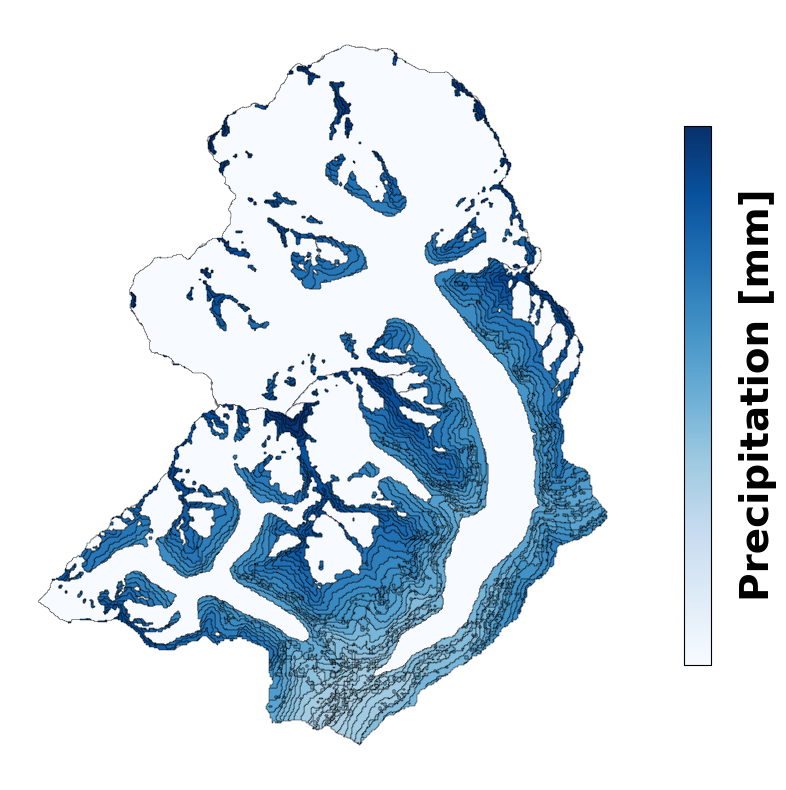


Precipitation statistics for time step 29:
  Min: 0.00 mm
  Max: 49.11 mm
  Mean: 14.02 mm
  Std: 15.67 mm


In [34]:

base_dir = '/home/jberg/OneDrive/Raven_Switzerland/02_model_setups_coupled'
gauge_id = 2161
hru_precip_data = plot_hru_precipitation(base_dir, gauge_id, time_step=29)

Processing gauge 2161...
Loading precipitation NetCDF...
NetCDF variables: ['swiss_lv95_coordinates', 'RhiresD', 'elevation']
NetCDF dimensions: FrozenMappingWarningOnValuesAccess({'time': 7671, 'N': 22, 'E': 17})
Using precipitation variable: RhiresD
Extracted time step 29: 2000-01-30T00:00:00.000000000
Precipitation data shape: (22, 17)
Precipitation range: 14.50 to 59.52
Parsing GridWeights.txt...
Number of HRUs: 97
Number of grid cells: 374
Loaded 2426 grid weight entries
HRU range: 1 to 97
Cell range: 8 to 366
Calculating HRU precipitation...
Flattened precipitation shape: (374,)
Calculated precipitation for 97 HRUs
HRU precipitation statistics:
  Min: 16.47 mm
  Max: 51.83 mm
  Mean: 30.93 mm
  Std: 10.84 mm
Loading HRU shapefile...
Loaded 97 HRUs from shapefile
HRU columns: ['HRU_ID', 'Area_m2', 'Area_km2', 'Elev_Mean', 'Elev_Min', 'Elev_Max', 'Slope_deg', 'Aspect_deg', 'Landuse_Cl', 'Latitude', 'Longitude', 'Glacier_Cl', 'Aspect_Cl', 'geometry']
Merged precipitation data for 97

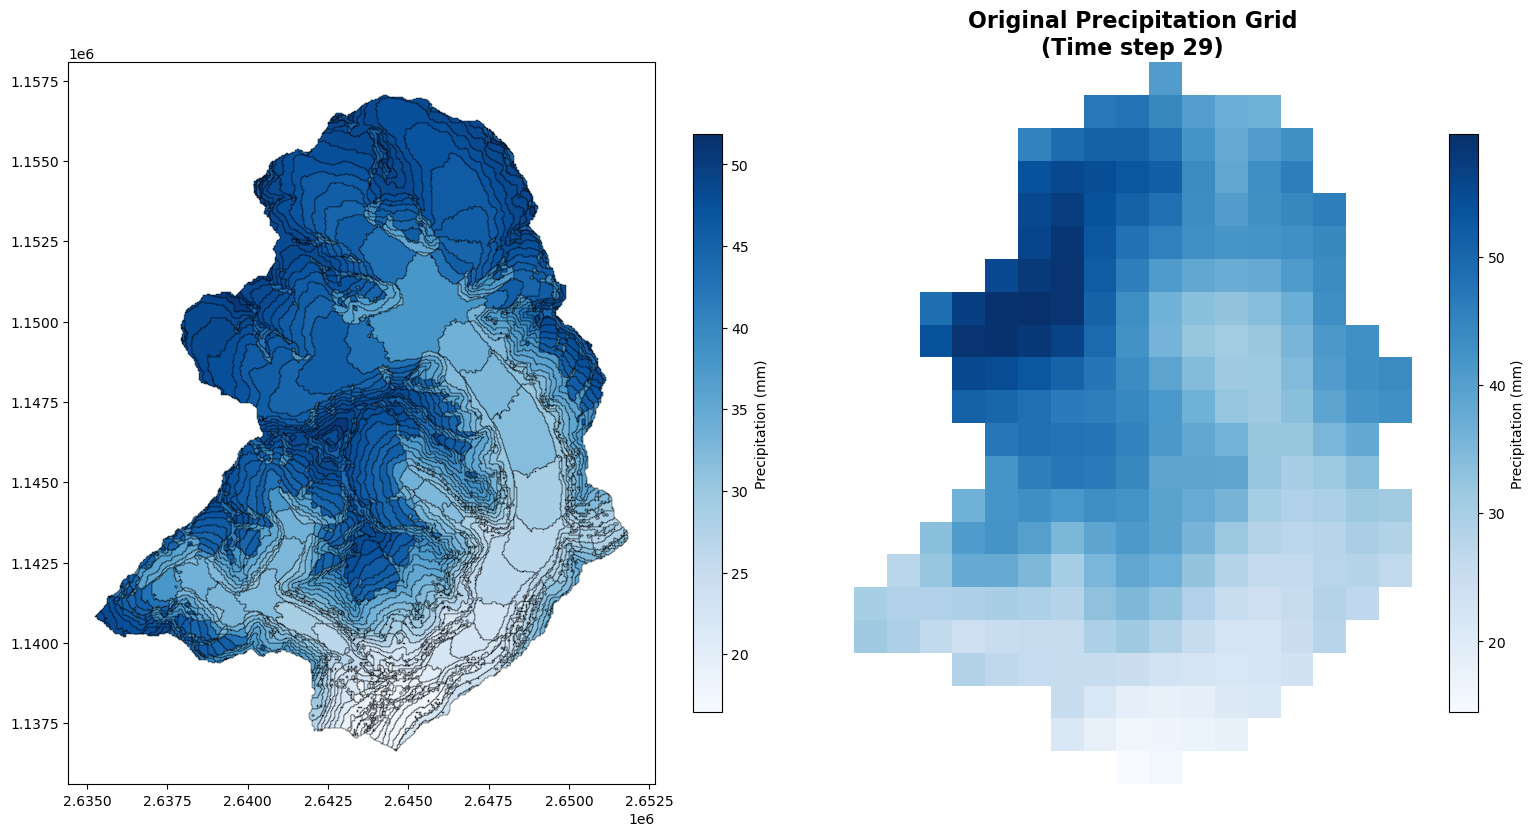

Saved bar plot to: /home/jberg/OneDrive/Paper_writing/Paper_1/Figures/methodology/hru_precipitation_bars_gauge_2161_t29.png


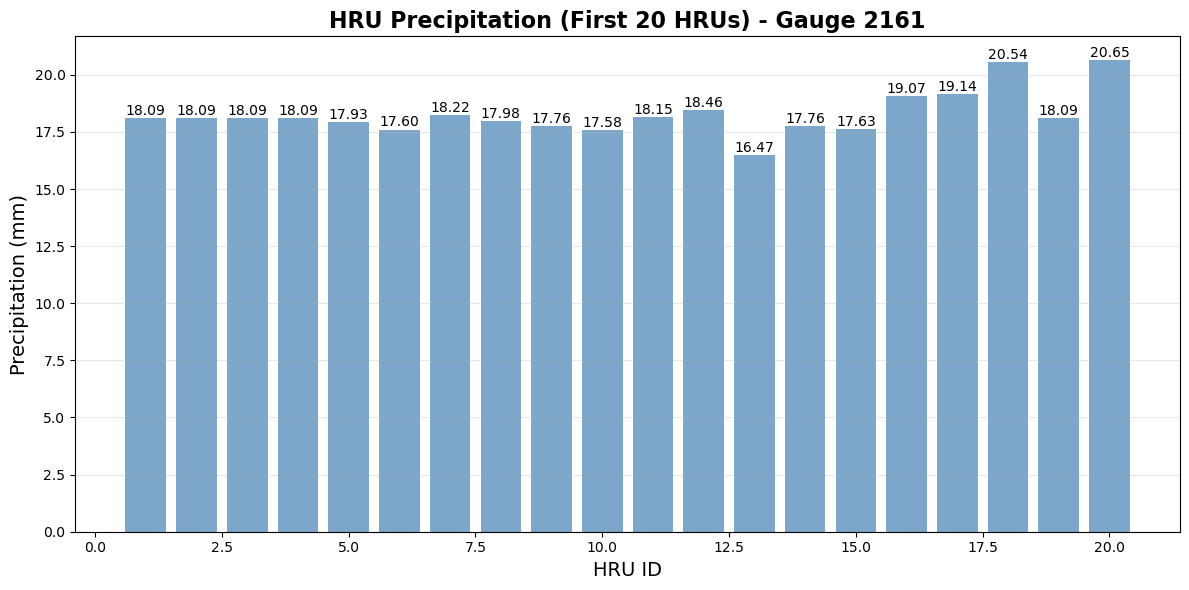


Processing complete for gauge 2161!

Summary for gauge 2161:
  min_precip: 16.468725204467773
  max_precip: 51.831119537353516
  mean_precip: 30.9341983795166
  std_precip: 10.836543083190918
  num_hrus: 97
  num_grid_weights: 2426


In [13]:
def calculate_and_plot_hru_precipitation_from_gridweights(gauge_id, base_dir, time_step=0, save_figs=True):
    """
    Calculate HRU precipitation using GridWeights.txt and plot the results
    
    Parameters
    ----------
    gauge_id : str or int
        Gauge ID for the catchment
    base_dir : str
        Base directory containing model setups
    time_step : int
        Time step to extract from NetCDF (default: 0)
    save_figs : bool
        Whether to save figures
        
    Returns
    -------
    dict
        Dictionary containing HRU precipitation data and other outputs
    """
    import geopandas as gpd
    import matplotlib.pyplot as plt
    import xarray as xr
    import numpy as np
    import pandas as pd
    import os
    from pathlib import Path
    
    print(f"Processing gauge {gauge_id}...")
    
    # Define file paths
    data_dir = Path(base_dir) / f"catchment_{gauge_id}" / "HBV" / "data_obs"
    topo_dir = Path(base_dir) / f"catchment_{gauge_id}" / "topo_files"
    
    precip_file = data_dir / "prec_Meteoswiss.nc"
    gridweights_file = data_dir / "GridWeights.txt"
    hru_shapefile = topo_dir / "HRU.shp"
    
    # Check if files exist
    missing_files = []
    for file_path, name in [(precip_file, "precipitation NetCDF"), 
                           (gridweights_file, "GridWeights.txt"), 
                           (hru_shapefile, "HRU shapefile")]:
        if not file_path.exists():
            missing_files.append(f"{name}: {file_path}")
    
    if missing_files:
        print("Missing files:")
        for file in missing_files:
            print(f"  - {file}")
        return None
    
    # Load precipitation NetCDF
    print("Loading precipitation NetCDF...")
    try:
        precip_ds = xr.open_dataset(precip_file)
        print(f"NetCDF variables: {list(precip_ds.data_vars.keys())}")
        print(f"NetCDF dimensions: {precip_ds.dims}")
        
        # Use RhiresD as the precipitation variable (this has the time dimension)
        precip_var = 'RhiresD'
        print(f"Using precipitation variable: {precip_var}")
        
        # Extract precipitation data for the specified time step
        if 'time' in precip_ds[precip_var].dims:
            precip_data = precip_ds[precip_var].isel(time=time_step)
            print(f"Extracted time step {time_step}: {precip_ds.time[time_step].values}")
        else:
            precip_data = precip_ds[precip_var]
            print("No time dimension found, using all data")
            
        print(f"Precipitation data shape: {precip_data.shape}")
        print(f"Precipitation range: {precip_data.min().values:.2f} to {precip_data.max().values:.2f}")
        
    except Exception as e:
        print(f"Error loading precipitation NetCDF: {e}")
        return None
    
    # Parse GridWeights.txt file
    print("Parsing GridWeights.txt...")
    try:
        grid_weights = []
        with open(gridweights_file, 'r') as f:
            lines = f.readlines()
            
        # Find the start of the data section
        data_started = False
        for line in lines:
            line = line.strip()
            if line.startswith(':NumberHRUs'):
                num_hrus = int(line.split()[-1])
                print(f"Number of HRUs: {num_hrus}")
            elif line.startswith(':NumberGridCells'):
                num_cells = int(line.split()[-1])
                print(f"Number of grid cells: {num_cells}")
            elif data_started and not line.startswith(':') and not line.startswith('#') and line:
                # Parse data line: HRU_ID Cell_ID Weight
                parts = line.split()
                if len(parts) >= 3:
                    try:
                        hru_id = int(parts[0])
                        cell_id = int(parts[1])
                        weight = float(parts[2])
                        grid_weights.append({'HRU_ID': hru_id, 'Cell_ID': cell_id, 'Weight': weight})
                    except ValueError:
                        continue
            elif '# [HRU ID] [Cell #] [w_kl]' in line:
                data_started = True
                
        grid_weights_df = pd.DataFrame(grid_weights)
        print(f"Loaded {len(grid_weights_df)} grid weight entries")
        print(f"HRU range: {grid_weights_df['HRU_ID'].min()} to {grid_weights_df['HRU_ID'].max()}")
        print(f"Cell range: {grid_weights_df['Cell_ID'].min()} to {grid_weights_df['Cell_ID'].max()}")
        
    except Exception as e:
        print(f"Error parsing GridWeights.txt: {e}")
        return None
    
    # Calculate precipitation for each HRU
    print("Calculating HRU precipitation...")
    try:
        # Convert precipitation data to 1D array (flattened)
        precip_flat = precip_data.values.flatten()
        print(f"Flattened precipitation shape: {precip_flat.shape}")
        
        # Calculate weighted precipitation for each HRU
        hru_precipitation = {}
        
        for hru_id in sorted(grid_weights_df['HRU_ID'].unique()):
            # Get all cells and weights for this HRU
            hru_weights = grid_weights_df[grid_weights_df['HRU_ID'] == hru_id]
            
            weighted_precip = 0.0
            total_weight = 0.0
            
            for _, row in hru_weights.iterrows():
                cell_id = int(row['Cell_ID'])  # Ensure it's an integer
                weight = float(row['Weight'])
                
                # Convert from 1-based to 0-based indexing
                cell_index = cell_id - 1
                
                # Check if cell_index is within bounds
                if 0 <= cell_index < len(precip_flat):
                    cell_precip = precip_flat[cell_index]
                    if not np.isnan(cell_precip):
                        weighted_precip += cell_precip * weight
                        total_weight += weight
                else:
                    print(f"Warning: Cell ID {cell_id} (index {cell_index}) is out of bounds for HRU {hru_id}")
            
            # Calculate final precipitation for this HRU
            if total_weight > 0:
                hru_precipitation[hru_id] = weighted_precip / total_weight
            else:
                hru_precipitation[hru_id] = 0.0
                
        print(f"Calculated precipitation for {len(hru_precipitation)} HRUs")
        
        # Convert to DataFrame for easier handling
        hru_precip_df = pd.DataFrame(list(hru_precipitation.items()), 
                                   columns=['HRU_ID', 'Precipitation'])
        
        print("HRU precipitation statistics:")
        print(f"  Min: {hru_precip_df['Precipitation'].min():.2f} mm")
        print(f"  Max: {hru_precip_df['Precipitation'].max():.2f} mm")
        print(f"  Mean: {hru_precip_df['Precipitation'].mean():.2f} mm")
        print(f"  Std: {hru_precip_df['Precipitation'].std():.2f} mm")
        
    except Exception as e:
        print(f"Error calculating HRU precipitation: {e}")
        return None
    
    # Load HRU shapefile and merge with precipitation data
    print("Loading HRU shapefile...")
    try:
        hru_gdf = gpd.read_file(hru_shapefile)
        print(f"Loaded {len(hru_gdf)} HRUs from shapefile")
        print(f"HRU columns: {hru_gdf.columns.tolist()}")
        
        # Merge precipitation data with HRU shapefile
        hru_gdf_merged = hru_gdf.merge(hru_precip_df, on='HRU_ID', how='left')
        
        # Fill NaN precipitation values with 0
        hru_gdf_merged['Precipitation'] = hru_gdf_merged['Precipitation'].fillna(0)
        
        print(f"Merged precipitation data for {len(hru_gdf_merged)} HRUs")
        
    except Exception as e:
        print(f"Error loading HRU shapefile: {e}")
        return None
    
    # Create visualization
    print("Creating visualization...")
    try:
        # Create save directory
        save_dir = '/home/jberg/OneDrive/Paper_writing/Paper_1/Figures/methodology'
        os.makedirs(save_dir, exist_ok=True)
        
        # Create the main plot
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
        
        # Plot 1: HRU precipitation from grid weights
        hru_plot = hru_gdf_merged.plot(
            column='Precipitation',
            cmap='Blues',
            edgecolor='black',
            linewidth=0.3,
            ax=ax1,
            legend=True,
            legend_kwds={'label': 'Precipitation (mm)', 'shrink': 0.8}
        )
        
        ax2.set_title(f'HRU Precipitation (Gauge {gauge_id})\nCalculated from GridWeights', 
                      fontsize=16, fontweight='bold')
        ax2.set_aspect('equal')
        ax2.axis('off')
        
        # Plot 2: Original precipitation grid (if possible to visualize)
        try:
            # Try to reshape precipitation data back to 2D for visualization
            if len(precip_data.shape) == 2:
                im = ax2.imshow(precip_data.values, cmap='Blues', origin='lower')
                plt.colorbar(im, ax=ax2, label='Precipitation (mm)', shrink=0.8)
                ax2.set_title(f'Original Precipitation Grid\n(Time step {time_step})', 
                             fontsize=16, fontweight='bold')
            else:
                # If we can't reshape, just show a histogram
                ax2.hist(precip_flat[~np.isnan(precip_flat)], bins=30, alpha=0.7, color='blue')
                ax2.set_xlabel('Precipitation (mm)')
                ax2.set_ylabel('Frequency')
                ax2.set_title(f'Precipitation Distribution\n(Time step {time_step})', 
                             fontsize=16, fontweight='bold')
                ax2.grid(True, alpha=0.3)
                
        except Exception as e:
            print(f"Warning: Could not create original precipitation plot: {e}")
            ax2.text(0.5, 0.5, 'Original precipitation\nvisualization not available', 
                    ha='center', va='center', transform=ax2.transAxes, fontsize=14)
            ax2.set_xlim(0, 1)
            ax2.set_ylim(0, 1)
        
        plt.tight_layout()
        
        # Save figure if requested
        if save_figs:
            save_path = f'{save_dir}/hru_precipitation_gridweights_gauge_{gauge_id}_t{time_step}.png'
            plt.savefig(save_path, bbox_inches='tight', transparent=True, dpi=300)
            print(f"Saved figure to: {save_path}")
        
        plt.show()
        
        # Create additional summary plot
        fig2, ax3 = plt.subplots(figsize=(12, 6))
        
        # Bar plot of precipitation by HRU (showing first 20 HRUs for readability)
        plot_hrus = hru_precip_df.head(20)
        bars = ax3.bar(plot_hrus['HRU_ID'], plot_hrus['Precipitation'], 
                      color='steelblue', alpha=0.7)
        
        ax3.set_xlabel('HRU ID', fontsize=14)
        ax3.set_ylabel('Precipitation (mm)', fontsize=14)
        ax3.set_title(f'HRU Precipitation (First 20 HRUs) - Gauge {gauge_id}', 
                     fontsize=16, fontweight='bold')
        ax3.grid(True, axis='y', alpha=0.3)
        
        # Add value labels on bars
        for bar, value in zip(bars, plot_hrus['Precipitation']):
            height = bar.get_height()
            ax3.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{value:.2f}', ha='center', va='bottom', fontsize=10)
        
        plt.tight_layout()
        
        if save_figs:
            save_path2 = f'{save_dir}/hru_precipitation_bars_gauge_{gauge_id}_t{time_step}.png'
            plt.savefig(save_path2, bbox_inches='tight', transparent=True, dpi=300)
            print(f"Saved bar plot to: {save_path2}")
        
        plt.show()
        
    except Exception as e:
        print(f"Error creating visualization: {e}")
        return None
    
    # Prepare return data
    result = {
        'hru_precipitation': hru_precip_df,
        'hru_shapefile': hru_gdf_merged,
        'grid_weights': grid_weights_df,
        'precipitation_data': precip_data,
        'summary_stats': {
            'min_precip': hru_precip_df['Precipitation'].min(),
            'max_precip': hru_precip_df['Precipitation'].max(),
            'mean_precip': hru_precip_df['Precipitation'].mean(),
            'std_precip': hru_precip_df['Precipitation'].std(),
            'num_hrus': len(hru_precip_df),
            'num_grid_weights': len(grid_weights_df)
        }
    }
    
    print(f"\nProcessing complete for gauge {gauge_id}!")
    return result

# Example usage:
base_dir = '/home/jberg/OneDrive/Raven_Switzerland/02_model_setups'
gauge_id = 2161
time_step = 29  # Use a different time step since time_step=0 has all zeros

result = calculate_and_plot_hru_precipitation_from_gridweights(
    gauge_id=gauge_id, 
    base_dir=base_dir, 
    time_step=time_step, 
    save_figs=True
)

if result:
    print(f"\nSummary for gauge {gauge_id}:")
    for key, value in result['summary_stats'].items():
        print(f"  {key}: {value}")

In [15]:
def plot_clean_hru_precipitation(gauge_id, base_dir, time_step=29, save_figs=True):
    """
    Create a clean HRU precipitation plot with no axes, labels, or titles

    Parameters
    ----------
    gauge_id : str or int
        Gauge ID for the catchment
    base_dir : str
        Base directory containing model setups
    time_step : int
        Time step to extract from NetCDF
    save_figs : bool
        Whether to save figures

    Returns
    -------
    dict
        Dictionary containing HRU precipitation data
    """
    import geopandas as gpd
    import matplotlib.pyplot as plt
    import xarray as xr
    import numpy as np
    import pandas as pd
    import os
    from pathlib import Path

    print(f"Processing gauge {gauge_id}...")

    # Define file paths
    data_dir = Path(base_dir) / f"catchment_{gauge_id}" / "HBV" / "data_obs"
    topo_dir = Path(base_dir) / f"catchment_{gauge_id}" / "topo_files"

    precip_file = data_dir / "prec_Meteoswiss.nc"
    gridweights_file = data_dir / "GridWeights.txt"
    hru_shapefile = topo_dir / "HRU.shp"

    # Check if files exist
    missing_files = []
    for file_path, name in [(precip_file, "precipitation NetCDF"),
                            (gridweights_file, "GridWeights.txt"),
                            (hru_shapefile, "HRU shapefile")]:
        if not file_path.exists():
            missing_files.append(f"{name}: {file_path}")

    if missing_files:
        print("Missing files:")
        for file in missing_files:
            print(f"  - {file}")
        return None

    # Load precipitation NetCDF
    print("Loading precipitation NetCDF...")
    try:
        precip_ds = xr.open_dataset(precip_file)
        precip_var = 'RhiresD'

        if 'time' in precip_ds[precip_var].dims:
            precip_data = precip_ds[precip_var].isel(time=time_step)
            print(f"Extracted time step {time_step}: {precip_ds.time[time_step].values}")
        else:
            precip_data = precip_ds[precip_var]

        print(f"Precipitation range: {precip_data.min().values:.2f} to {precip_data.max().values:.2f}")

    except Exception as e:
        print(f"Error loading precipitation NetCDF: {e}")
        return None

    # Parse GridWeights.txt file
    print("Parsing GridWeights.txt...")
    try:
        grid_weights = []
        with open(gridweights_file, 'r') as f:
            lines = f.readlines()

        data_started = False
        for line in lines:
            line = line.strip()
            if line.startswith(':NumberHRUs'):
                num_hrus = int(line.split()[-1])
                print(f"Number of HRUs: {num_hrus}")
            elif line.startswith(':NumberGridCells'):
                num_cells = int(line.split()[-1])
                print(f"Number of grid cells: {num_cells}")
            elif data_started and not line.startswith(':') and not line.startswith('#') and line:
                parts = line.split()
                if len(parts) >= 3:
                    try:
                        hru_id = int(parts[0])
                        cell_id = int(parts[1])
                        weight = float(parts[2])
                        grid_weights.append({'HRU_ID': hru_id, 'Cell_ID': cell_id, 'Weight': weight})
                    except ValueError:
                        continue
            elif '# [HRU ID] [Cell #] [w_kl]' in line:
                data_started = True

        grid_weights_df = pd.DataFrame(grid_weights)
        print(f"Loaded {len(grid_weights_df)} grid weight entries")

    except Exception as e:
        print(f"Error parsing GridWeights.txt: {e}")
        return None

    # Calculate precipitation for each HRU
    print("Calculating HRU precipitation...")
    try:
        precip_flat = precip_data.values.flatten()
        hru_precipitation = {}

        for hru_id in sorted(grid_weights_df['HRU_ID'].unique()):
            hru_weights = grid_weights_df[grid_weights_df['HRU_ID'] == hru_id]

            weighted_precip = 0.0
            total_weight = 0.0

            for _, row in hru_weights.iterrows():
                cell_id = int(row['Cell_ID'])
                weight = float(row['Weight'])
                cell_index = cell_id - 1

                if 0 <= cell_index < len(precip_flat):
                    cell_precip = precip_flat[cell_index]
                    if not np.isnan(cell_precip):
                        weighted_precip += cell_precip * weight
                        total_weight += weight

            if total_weight > 0:
                hru_precipitation[hru_id] = weighted_precip / total_weight
            else:
                hru_precipitation[hru_id] = 0.0

        hru_precip_df = pd.DataFrame(list(hru_precipitation.items()),
                                     columns=['HRU_ID', 'Precipitation'])

        print(f"Precipitation range: {hru_precip_df['Precipitation'].min():.2f} to {hru_precip_df['Precipitation'].max():.2f} mm")

    except Exception as e:
        print(f"Error calculating HRU precipitation: {e}")
        return None

    # Load HRU shapefile and merge with precipitation data
    print("Loading HRU shapefile...")
    try:
        hru_gdf = gpd.read_file(hru_shapefile)
        hru_gdf_merged = hru_gdf.merge(hru_precip_df, on='HRU_ID', how='left')
        hru_gdf_merged['Precipitation'] = hru_gdf_merged['Precipitation'].fillna(0)

    except Exception as e:
        print(f"Error loading HRU shapefile: {e}")
        return None

    # Create clean visualization
    print("Creating clean visualization...")
    try:
        # Create save directory
        save_dir = '/home/jberg/OneDrive/Paper_writing/Paper_1/Figures/methodology'
        os.makedirs(save_dir, exist_ok=True)

        # Create single clean plot
        fig, ax = plt.subplots(figsize=(10, 8))

        # Plot HRU precipitation with clean styling
        hru_gdf_merged.plot(
            column='Precipitation',
            cmap='Blues',
            edgecolor='black',
            linewidth=0.5,
            ax=ax
        )

        # Add colorbar with no ticks/tick labels and bigger label
        sm = plt.cm.ScalarMappable(
            cmap='Blues',
            norm=plt.Normalize(
                vmin=hru_gdf_merged['Precipitation'].min(),
                vmax=hru_gdf_merged['Precipitation'].max()
            )
        )
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax, shrink=0.8, pad=0.02)
        cbar.set_label('Precipitation [mm]', fontsize=28, labelpad=20, fontweight='bold')
        cbar.set_ticks([])  # Remove all ticks
        cbar.ax.tick_params(labelsize=0, length=0)  # Remove tick labels and ticks

        # Remove all axes, labels, and titles
        ax.set_aspect('equal')
        ax.axis('off')

        # Remove any padding/margins
        plt.subplots_adjust(left=0, right=0.85, top=1, bottom=0)

        # Save figure if requested
        if save_figs:
            save_path = f'{save_dir}/clean_hru_precipitation_gauge_{gauge_id}_t{time_step}.png'
            plt.savefig(save_path, bbox_inches='tight', transparent=True, dpi=300,
                        facecolor='white', edgecolor='none')
            print(f"Saved clean figure to: {save_path}")

        plt.show()

    except Exception as e:
        print(f"Error creating visualization: {e}")
        return None

    # Return the data
    result = {
        'hru_precipitation': hru_precip_df,
        'hru_shapefile': hru_gdf_merged,
        'summary_stats': {
            'min_precip': hru_precip_df['Precipitation'].min(),
            'max_precip': hru_precip_df['Precipitation'].max(),
            'mean_precip': hru_precip_df['Precipitation'].mean(),
            'std_precip': hru_precip_df['Precipitation'].std(),
            'num_hrus': len(hru_precip_df)
        }
    }

    print(f"Processing complete for gauge {gauge_id}!")
    return result

Processing gauge 2161...
Loading precipitation NetCDF...
Extracted time step 29: 2000-01-30T00:00:00.000000000
Precipitation range: 14.50 to 59.52
Parsing GridWeights.txt...
Number of HRUs: 97
Number of grid cells: 374
Loaded 2426 grid weight entries
Calculating HRU precipitation...
Precipitation range: 16.47 to 51.83 mm
Loading HRU shapefile...
Creating clean visualization...
Saved clean figure to: /home/jberg/OneDrive/Paper_writing/Paper_1/Figures/methodology/clean_hru_precipitation_gauge_2161_t29.png


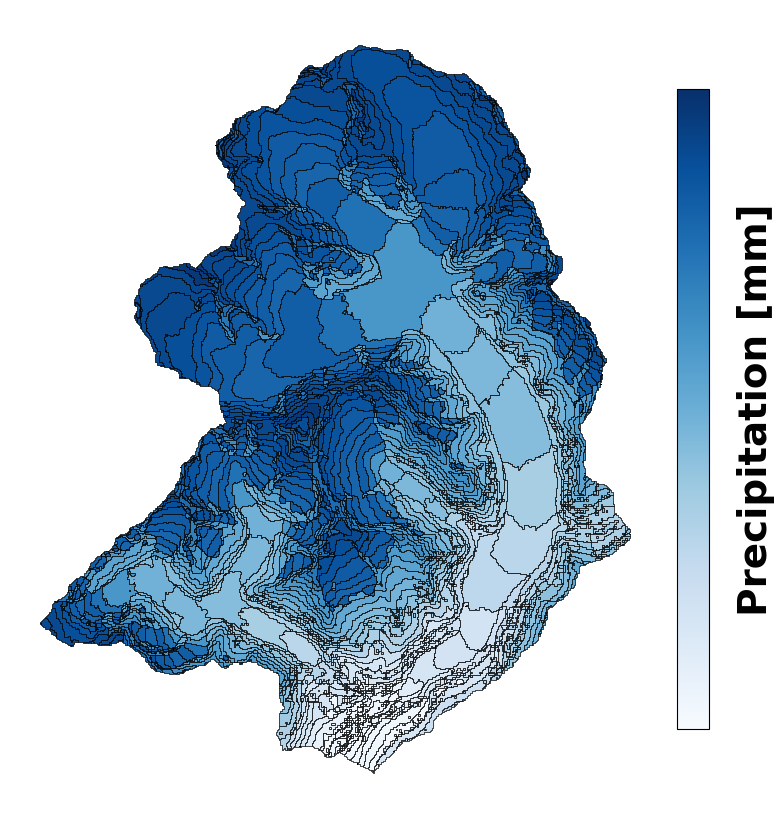

Processing complete for gauge 2161!


In [16]:
# Usage
base_dir = '/home/jberg/OneDrive/Raven_Switzerland/02_model_setups'
gauge_id = 2161
time_step = 29

result = plot_clean_hru_precipitation(
    gauge_id=gauge_id, 
    base_dir=base_dir, 
    time_step=time_step, 
    save_figs=True
)

Loading calibration results from: /home/jberg/OneDrive/Raven_Switzerland/09_runs_paper_old_HBV_KGE_NP/catchment_2200_c/HBV/output/calibration_results_2200_HBV_20250807_150523.csv
Loaded 5241 calibration iterations
Columns: ['HBV_RainSnow_Temp', 'HBV_Melt_Fact', 'HBV_Refreeze_Fact', 'HBV_Snow_SWI', 'HBV_Porosity', 'HBV_Field_Cap', 'HBV_Beta', 'HBV_Max_Perc_Rate_Fast_Res', 'HBV_BaseFlow_Coeff_Fast_Res', 'HBV_BaseFlow_Coeff_Slow_Res', 'HBV_T_Conc_Max_Bas', 'HBV_Sat_Wilt', 'HBV_Baseflow_N', 'HBV_Max_Cap_Rise_Rate', 'HBV_Thickness_Topsoil', 'HBV_Melt_For_Corr', 'HBV_Glac_Storage_Effect', 'objective', 'obj_function', 'timestamp', 'validation_obj']
Objective range: 0.4544 to 0.9116
Saved figure to: /home/jberg/OneDrive/Paper_writing/Paper_1/Figures/methodology/optimization_convergence_2200_HBV.png


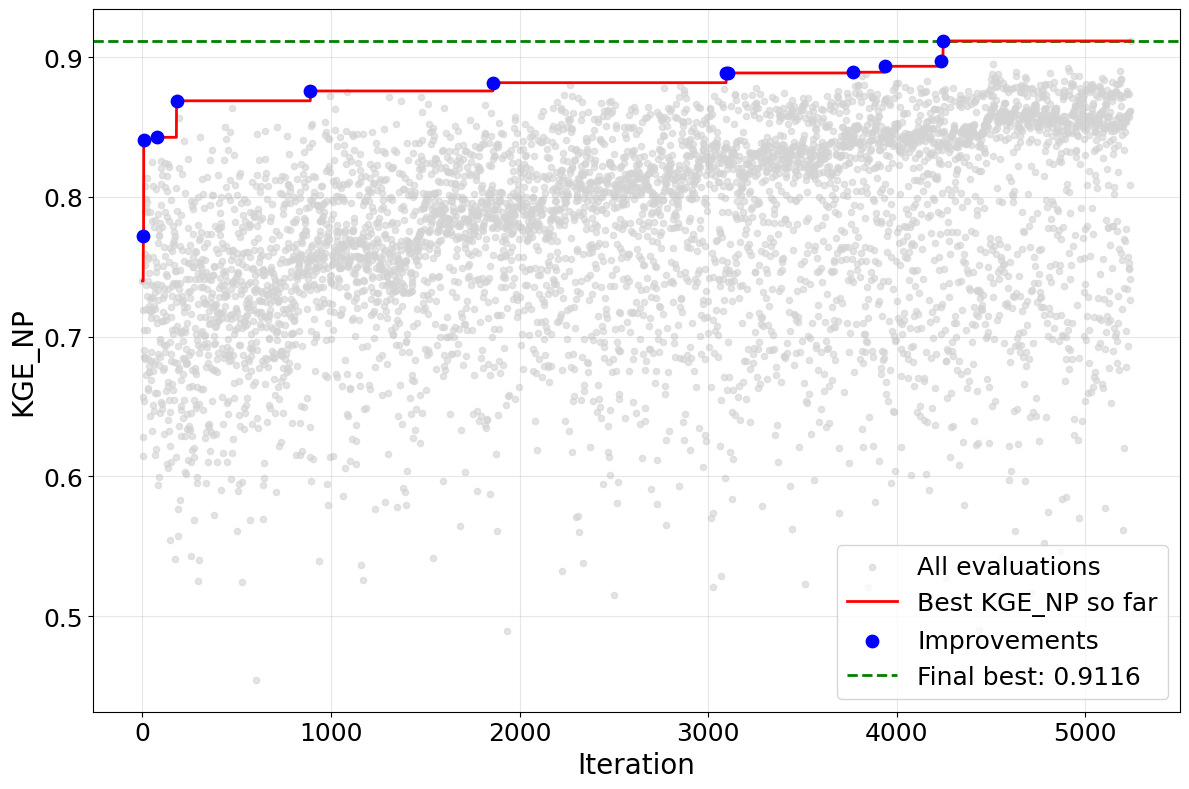


Optimization Summary for 2200:
  Total iterations: 5241
  Number of improvements: 12
  Initial KGE_NP: 0.7398
  Final KGE_NP: 0.9116
  Total improvement: 0.1718
  Best 10% of runs: 0.8571


In [ ]:
def plot_optimization_convergence(csv_path, gauge_id, save_figs=True):
    """
    Plot optimization convergence similar to SCEUA optimization plot
    
    Parameters
    ----------
    csv_path : str
        Path to the calibration results CSV file
    gauge_id : str or int
        Gauge ID for labeling
    save_figs : bool
        Whether to save the figure
    """
    import pandas as pd
    import matplotlib.pyplot as plt
    import numpy as np
    import os
    
    print(f"Loading calibration results from: {csv_path}")
    
    # Load the CSV file
    try:
        df = pd.read_csv(csv_path)
        print(f"Loaded {len(df)} calibration iterations")
        print(f"Columns: {df.columns.tolist()}")
        
        # Check if 'objective' column exists
        if 'objective' not in df.columns:
            print("Error: 'objective' column not found in CSV file")
            return None
            
        # Get objective values
        objective_values = df['objective'].values
        iterations = np.arange(len(objective_values))
        
        print(f"Objective range: {objective_values.min():.4f} to {objective_values.max():.4f}")
        
    except Exception as e:
        print(f"Error loading CSV file: {e}")
        return None
    
    # Calculate running best (assuming higher KGE_NP is better)
    running_best = np.maximum.accumulate(objective_values)
    
    # Find improvement points (where running best changes)
    improvement_mask = np.diff(running_best, prepend=running_best[0]) > 0
    improvement_iterations = iterations[improvement_mask]
    improvement_values = objective_values[improvement_mask]
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Plot all evaluations as gray scatter points
    ax.scatter(iterations, objective_values, 
              c='lightgray', alpha=0.6, s=20, 
              label='All evaluations', zorder=1)
    
    # Plot running best as red line
    ax.plot(iterations, running_best, 
            color='red', linewidth=2, 
            label='Best KGE_NP so far', zorder=3)
    
    # Plot improvements as blue circles
    ax.scatter(improvement_iterations, improvement_values,
              color='blue', s=80, 
              label='Improvements', zorder=4)
    
    # Add horizontal line for final best value
    final_best = running_best[-1]
    ax.axhline(y=final_best, color='green', linestyle='--', linewidth=2,
              label=f'Final best: {final_best:.4f}', zorder=2)
    
    # Customize the plot
    ax.set_xlabel('Iteration', fontsize=20)
    ax.set_ylabel('KGE_NP', fontsize=20)
    # Remove title
    # ax.set_title(f'SCEUA Optimization Convergence for {gauge_id} HBV', fontsize=18, fontweight='bold')
    
    # Set tick parameters with bigger font
    ax.tick_params(axis='both', which='major', labelsize=18)
    
    # Add grid
    ax.grid(True, alpha=0.3)
    
    # Add legend with bigger font
    ax.legend(fontsize=18, loc='lower right')
    
    # Set y-axis limits with some padding
    y_min = objective_values.min()
    y_max = objective_values.max()
    y_range = y_max - y_min
    ax.set_ylim(y_min - 0.05 * y_range, y_max + 0.05 * y_range)
    
    plt.tight_layout()
    
    # Save figure if requested
    if save_figs:
        save_dir = '/home/jberg/OneDrive/Paper_writing/Paper_1/Figures/methodology'
        os.makedirs(save_dir, exist_ok=True)
        save_path = f'{save_dir}/optimization_convergence_{gauge_id}_HBV.png'
        plt.savefig(save_path, bbox_inches='tight', transparent=True, dpi=300)
        print(f"Saved figure to: {save_path}")
    
    plt.show()
    
    # Print summary statistics
    print(f"\nOptimization Summary for {gauge_id}:")
    print(f"  Total iterations: {len(objective_values)}")
    print(f"  Number of improvements: {len(improvement_values)}")
    print(f"  Initial KGE_NP: {objective_values[0]:.4f}")
    print(f"  Final KGE_NP: {final_best:.4f}")
    print(f"  Total improvement: {final_best - objective_values[0]:.4f}")
    print(f"  Best 10% of runs: {np.percentile(objective_values, 90):.4f}")
    
    return {
        'iterations': iterations,
        'objective_values': objective_values,
        'running_best': running_best,
        'final_best': final_best,
        'improvement_iterations': improvement_iterations,
        'improvement_values': improvement_values
    }

# Usage
csv_path = '/home/jberg/OneDrive/Raven_Switzerland/09_runs_paper_old_HBV_KGE_NP/catchment_2200_c/HBV/output/calibration_results_2200_HBV_20250807_150523.csv'
gauge_id = 2200

result = plot_optimization_convergence(csv_path, gauge_id, save_figs=True)